In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data=pd.read_excel(r"/Users/macbook/Documents/data/FL199.xlsx").values
y = data[:,0]
X = data[:,1:]
# Define the parameter grid for grid search
param_grid = {'n_estimators': [20, 100, 200],
              'max_depth': [5, 10, 20, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': ['auto', 'sqrt']}

# Create a random forest regressor object
rf = RandomForestRegressor()

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=30)

# Perform grid search cross-validation to find the best hyperparameters
grid_search = GridSearchCV(rf, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train.ravel())

# Print the best hyperparameters
print('Best hyperparameters:', grid_search.best_params_)

/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it i

Best hyperparameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


R-squared score: 0.17882627066003953
Mean Squared Error: 0.14912558853012797
Mean Absolute Error: 0.301918375670372


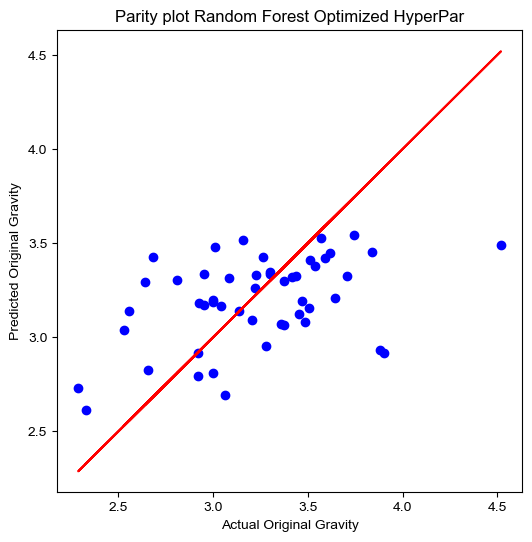

In [16]:
# Use the best hyperparameters to fit the random forest model
rf = RandomForestRegressor(**grid_search.best_params_)
rf.fit(x_train, y_train.ravel())

# Predicting the test set results
y_pred_diff_rf = rf.predict(x_test)

r2_diff_rf = r2_score(y_test, y_pred_diff_rf)
mse_diff_rf = mean_squared_error(y_test, y_pred_diff_rf)
mae_diff_rf = mean_absolute_error(y_test, y_pred_diff_rf)

print('R-squared score:', r2_diff_rf)
print('Mean Squared Error:', mse_diff_rf)
print('Mean Absolute Error:', mae_diff_rf)

# plot parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_diff_rf, color='blue')
plt.plot(y_test, y_test, color='red')
plt.title('Parity plot Random Forest Optimized HyperPar')
plt.xlabel('Actual Original Gravity')
plt.ylabel('Predicted Original Gravity')
plt.show()

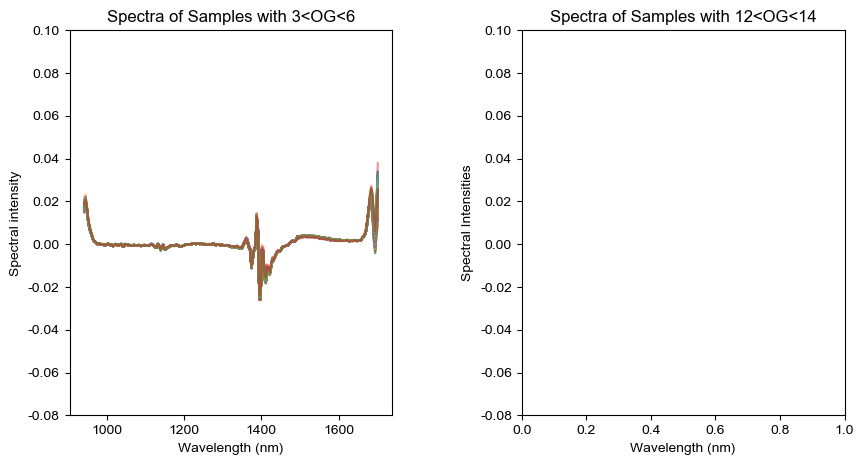

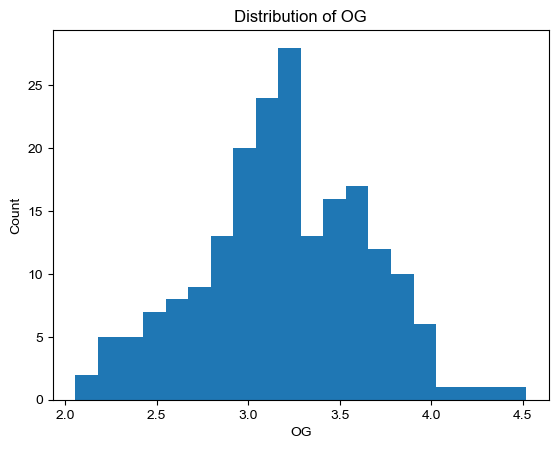

In [17]:
wavelengths = np.linspace(942, 1701, X.shape[1])

mask_low = (y.reshape(-1) >= 3) & (y.reshape(-1) <= 6) 
X_filtered_low = X[mask_low, :]
X_filtered_diff_low = np.gradient(X_filtered_low, axis=1)

mask_high = (y.reshape(-1) >= 12) & (y.reshape(-1) <= 14) 
X_filtered_high = X[mask_high, :]
X_filtered_diff_high = np.gradient(X_filtered_high, axis=1)

fig = plt.figure(figsize=(10, 5))

# Plot Low End of the Spectra
plt.subplot(1, 2, 1)
for i in range(X_filtered_diff_low.shape[0]):
    plt.plot(wavelengths, X_filtered_diff_low[i, :], alpha=0.5)

plt.title('Spectra of Samples with 3<OG<6')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral intensity')
plt.ylim(-0.08, 0.1)

# plot Scaled Spectra
plt.subplot(1, 2, 2)
for i in range(X_filtered_diff_high.shape[0]):
    plt.plot(wavelengths, X_filtered_diff_high[i, :], alpha=0.5)

plt.title('Spectra of Samples with 12<OG<14')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Intensities')
plt.ylim(-0.08, 0.1)
plt.subplots_adjust(wspace=0.4)
plt.show()


plt.hist(y, bins=20)
plt.title('Distribution of OG')
plt.xlabel('OG')
plt.ylabel('Count')
plt.show()

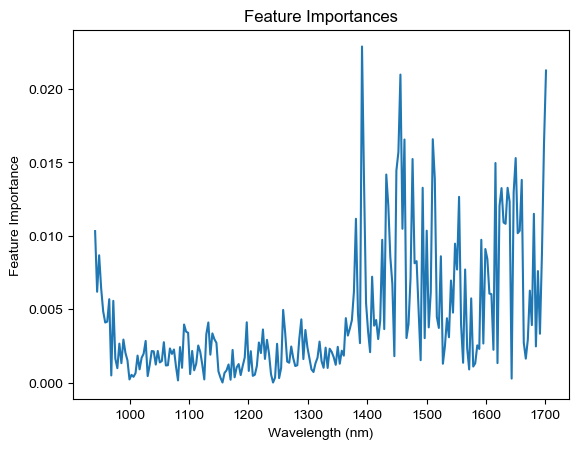

In [18]:
#First, we evaluate the feature importance:
feat_importances = rf.feature_importances_
plt.plot(wavelengths, feat_importances)
plt.title('Feature Importances')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Feature Importance')
plt.show()

ValueError: x and y must be the same size

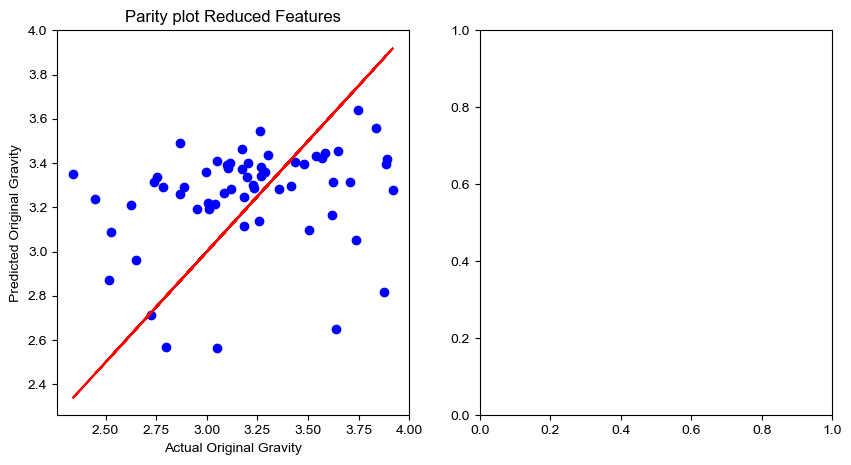

In [20]:
# Get indices of top n most important features
n = 50 # This parameter can be optimized
indices = np.argsort(feat_importances)[::-1][:n]
# Select only the columns corresponding to the top n features
X_top = X[:, indices]

# Splitting the data into training and test sets
X_train_rf_red, X_test_rf_red, y_train, y_test = train_test_split(X_top, y, test_size=0.30, random_state=42)


# Use the best hyperparameters to fit the random forest model
rf = RandomForestRegressor(max_depth= 10, max_features= 'sqrt', min_samples_leaf=1, min_samples_split= 2, n_estimators=100, random_state=42)
rf.fit(X_train_rf_red, y_train.ravel())
# Make predictions
y_pred_rf_red = rf.predict(X_test_rf_red)

fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
# plot parity plot Reduced Features
plt.scatter(y_test, y_pred_rf_red, color='blue')
plt.plot(y_test, y_test, color='red')
plt.title('Parity plot Reduced Features')
plt.xlabel('Actual Original Gravity')
plt.ylabel('Predicted Original Gravity')
plt.subplot(1, 2, 2)
# plot parity plot All Featre
plt.scatter(y_test, y_pred_diff_rf, color='blue')
plt.plot(y_test, y_test, color='red')
plt.title('Parity plot All Features')
plt.xlabel('Actual Original Gravity')
plt.ylabel('Predicted Original Gravity')
plt.show()

r2_diff_rf = r2_score(y_test, y_pred_diff_rf)
mse_diff_rf = mean_squared_error(y_test, y_pred_diff_rf)
mae_diff_rf = mean_absolute_error(y_test, y_pred_diff_rf)

print('R-squared score All Features:', r2_diff_rf)
print('Mean Squared Error All Features:', mse_diff_rf)
print('Mean Absolute Error All Features:', mae_diff_rf)

r2_rf_red = r2_score(y_test, y_pred_rf_red)
mse_rf_red = mean_squared_error(y_test, y_pred_rf_red)
mae_rf_red = mean_absolute_error(y_test, y_pred_rf_red)

print('R-squared score Top Features:', r2_rf_red)
print('Mean Squared Error Top Features:', mse_rf_red)
print('Mean Absolute Error Top Features:', mae_rf_red)